# **Detección de Fraude en Transacciones Financieras**
## **Análisis Exploratorio de Datos (EDA)**

**Dataset:** IEEE-CIS Fraud Detection — [Kaggle](https://www.kaggle.com/c/ieee-fraud-detection)  
**Autor:** Juan Camilo Silva Perilla  
**Fecha:** Abril 2026

---

El dataset contiene 590,540 transacciones reales de comercio electrónico, etiquetadas como fraudulentas o legítimas. Proviene de una competencia de Vesta Corporation en Kaggle y es ampliamente usado como benchmark en detección de fraude financiero.

Este notebook cubre la fase de EDA del pipeline completo:
limpieza → exploración → hipótesis → modelado (siguiente notebook).

El objetivo es identificar qué variables tienen mayor poder predictivo sobre el fraude,entender el desbalance de clases, y definir la estrategia de feature engineering para el modelo de clasificación.

In [68]:
import pandas as pd

df = pd.read_csv("data/train_transaction.csv")

df.shape

(590540, 394)

In [69]:
df.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'V330', 'V331', 'V332', 'V333', 'V334', 'V335', 'V336', 'V337', 'V338',
       'V339'],
      dtype='object', length=394)

Quiero conocer que variables pueden tener nulos, porque a futuro pueden ser variables relevantes a tener en cuenta, porque pueden presentar problemas por falta de datos para entrenar, y además poder entender que está pasando en el dataset.

In [70]:
df.isnull().sum()

TransactionID          0
isFraud                0
TransactionDT          0
TransactionAmt         0
ProductCD              0
                   ...  
V335              508189
V336              508189
V337              508189
V338              508189
V339              508189
Length: 394, dtype: int64

In [71]:
df.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,55.000000,160000.000000,160000.000000,160000.000000,55125.000000,55125.00000,55125.000000,104060.000000,104060.000000,104060.000000


## **Hipotesis**

Las transacciones fraudulentas deberían tener una mayor cantidad de dinero

In [72]:
df.groupby("isFraud")['TransactionAmt'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,134.511665,239.395078,0.251,43.970,68.5,120.0,31937.391
1,20663.0,149.244779,232.212163,0.292,35.044,75.0,161.0,5191.000


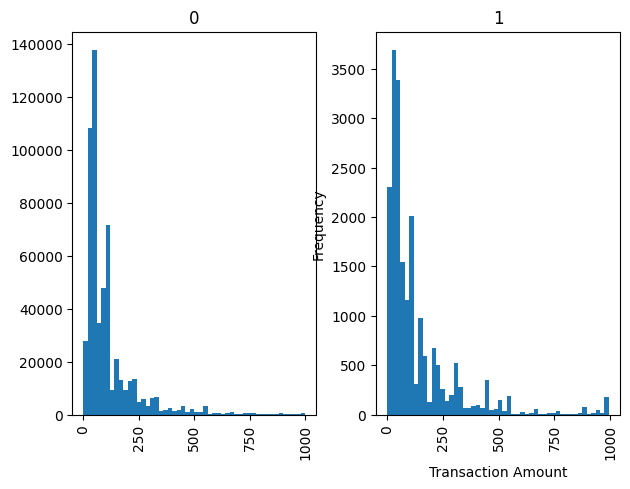

In [74]:
import matplotlib.pyplot as plt

df[df['TransactionAmt'] < 1000].hist(column='TransactionAmt', by='isFraud', bins=50)
plt.tight_layout()
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

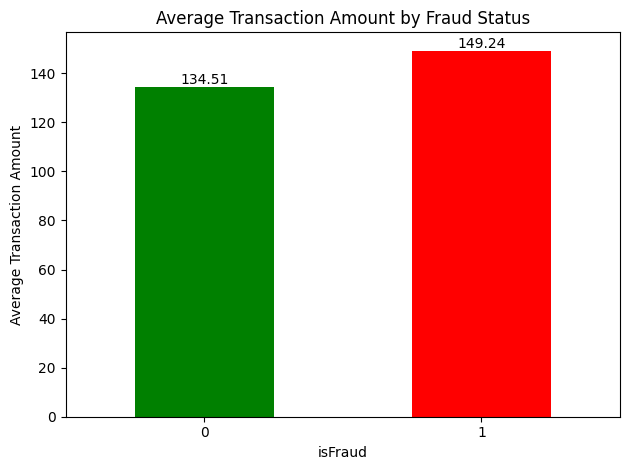

In [99]:
suma_isFraud = df.groupby('isFraud')['TransactionAmt'].mean()
ax = suma_isFraud.plot(kind='bar', color=['green', 'red'])
for patch in ax.patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width() / 2, height, f'{height:.2f}', ha='center', va='bottom')
plt.xlabel('isFraud')
plt.ylabel('Average Transaction Amount')
plt.title('Average Transaction Amount by Fraud Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

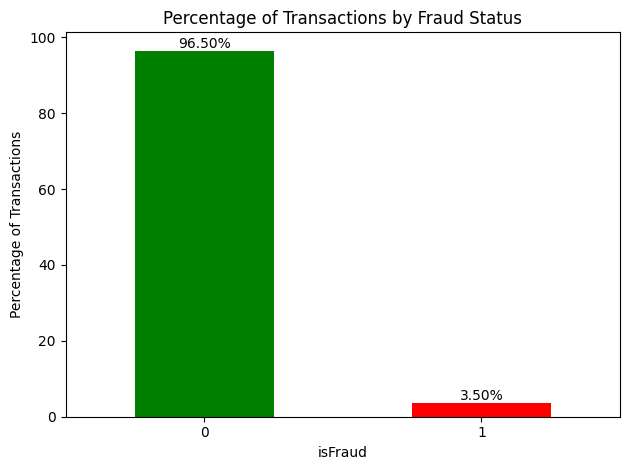

In [92]:
suma_isFraud_count =  df['isFraud'].value_counts(normalize=True) * 100
ax = suma_isFraud_count.plot(kind='bar', color=['green', 'red'])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

for patch in ax.patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width() / 2, height, f'{height:.2f}%', ha='center', va='bottom')
    
plt.ylabel('Percentage of Transactions')
plt.title('Percentage of Transactions by Fraud Status')
plt.xticks(rotation=0)
plt.xlabel('isFraud')
plt.tight_layout()
plt.show()


Gracias a la gráfica de "Average Transaction Amount by Fraud Status", las transacciones fraudulentas, en promedio tienen un poco mas de dinero, lo que podría tener sentido al intentar sacar dinero.

Y gracias a la gráfica "Percentage of Transactions by Fraud Status", ya que se evidencia algo que se sabía de antemano, y es el gran desbalance que hay en el porcentaje de transacciones fraudulentas, ya que son muy pocas.

Si tomamos las dos gráficas, podremos evidenciar algo bastante preocupante, y es que aunque sean tan pocas transacciones malas, la cantidad de dinero es absurdo, ya que con solo 3.50% de las transacciones, llega a un promedio de casi 150 dólares por transacción.

## **Segundo dataset**

Existen dos dataset, ya que se simula la vida real, originalmente la información se guarda separada y normalizada, como en una base de datos, la información no se encuentra en un solo lugar, hay diferentes tablas, así como fuentes.

In [78]:
df_train_identity = pd.read_csv("data/train_identity.csv")

In [94]:
df_train_identity.describe()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,1.442330e+05,144233.000000,140872.000000,66324.000000,66324.000000,136865.000000,136865.000000,5155.000000,5155.000000,74926.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.236329e+06,-10.170502,174716.584708,0.060189,-0.058938,1.615585,-6.698710,13.285354,-38.600388,0.091023,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.788496e+05,14.347949,159651.816856,0.598231,0.701015,5.249856,16.491104,11.384207,26.084899,0.983842,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987004e+06,-100.000000,1.000000,-13.000000,-28.000000,-72.000000,-100.000000,-46.000000,-100.000000,-36.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.077142e+06,-10.000000,67992.000000,0.000000,0.000000,0.000000,-6.000000,5.000000,-48.000000,0.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.198818e+06,-5.000000,125800.500000,0.000000,0.000000,0.000000,0.000000,14.000000,-34.000000,0.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.392923e+06,-5.000000,228749.000000,0.000000,0.000000,1.000000,0.000000,22.000000,-23.000000,0.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577534e+06,0.000000,999595.000000,10.000000,0.000000,52.000000,0.000000,61.000000,0.000000,25.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


In [79]:
df_complete = df.merge(df_train_identity, on='TransactionID', how='left')

In [80]:
print(df_complete.shape)
df_complete.columns

(590540, 434)


Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=434)

In [98]:
df_complete['DeviceType'].isnull().sum()

np.int64(449730)

Se espera poder encontrar que dispositivo puede ser más usado al momento de realizar fraude, encontrar un patrón de cual es el más usado.

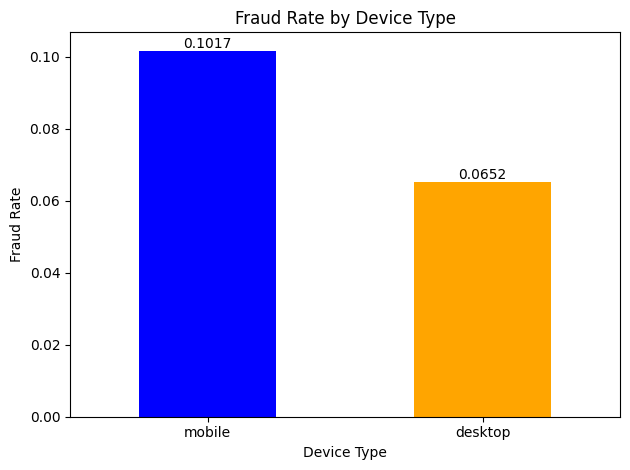

In [95]:
suma_device = df_complete.groupby('DeviceType')['isFraud'].mean().sort_values(ascending=False)
ax = suma_device.plot(kind='bar', color=['blue', 'orange'])

for patch in ax.patches:
    height = patch.get_height()
    ax.text(patch.get_x() + patch.get_width() / 2, height, f'{height:.4f}', ha='center', va='bottom')
plt.xlabel('Device Type')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by Device Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **Qué se encontró?**

Los dispositivos moviles, son los más usados al momento de las transacciones fraudulentas en promedio, puede tener sentido por temas de seguridad, aunque hay que ver cómo se comportará en el modelado.

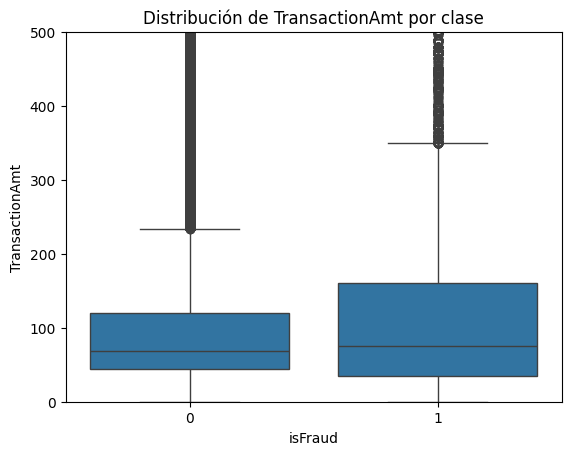

In [ ]:
import seaborn as sns

sns.boxplot(data=df, x='isFraud', y='TransactionAmt')
plt.ylim(0, 500)  # limita el eje para que se vea bien — hay outliers enormes
plt.title('Distribution of transaction amounts by class')
plt.show()

In [84]:
df_complete.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,...,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,...,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,...,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,...,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000,100.000000,100.000000,10.000000,...,100.000000,10.000000,100.000000,100.000000,100.000000,10.000000,11.000000,100.000000,100.000000,0.000000
25%,3.134635e+06,0.000000,3.027058e+06,43.321000,6019.000000,214.000000,150.000000,166.000000,204.000000,87.000000,...,166.000000,13.000000,266.000000,256.000000,252.000000,14.000000,11.000000,321.000000,119.000000,24.000000
50%,3.282270e+06,0.000000,7.306528e+06,68.769000,9678.000000,361.000000,150.000000,226.000000,299.000000,87.000000,...,166.000000,15.000000,341.000000,472.000000,252.000000,14.000000,11.000000,321.000000,149.000000,24.000000
75%,3.429904e+06,0.000000,1.124662e+07,125.000000,14184.000000,512.000000,150.000000,226.000000,330.000000,87.000000,...,225.000000,15.000000,427.000000,533.000000,486.500000,14.000000,15.000000,371.000000,169.000000,32.000000
max,3.577539e+06,1.000000,1.581113e+07,31937.391000,18396.000000,600.000000,231.000000,237.000000,540.000000,102.000000,...,229.000000,29.000000,671.000000,661.000000,854.000000,44.000000,26.000000,548.000000,216.000000,32.000000


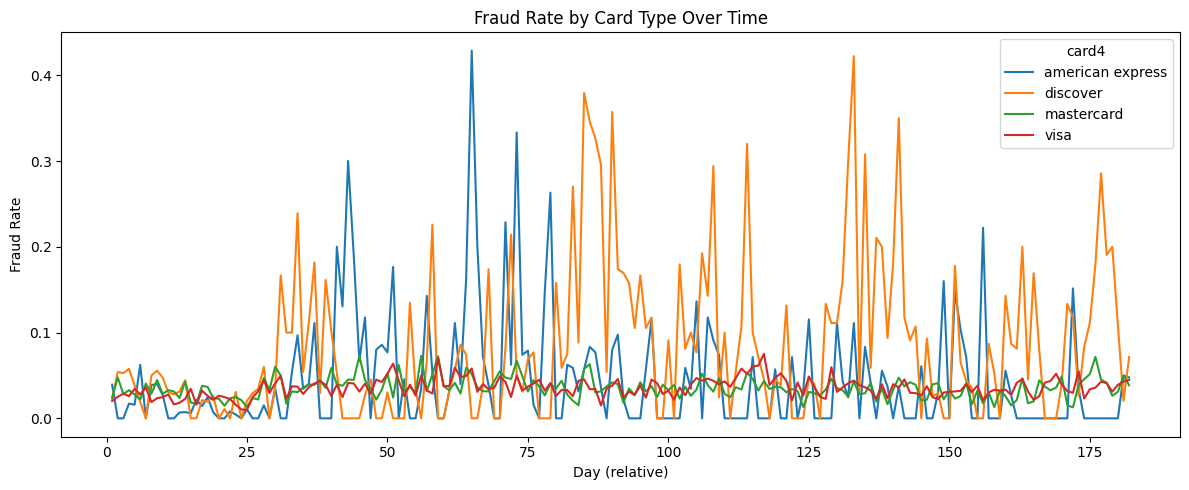

In [100]:
df_temp = df_complete.copy()

df_temp['day'] = (df_temp['TransactionDT'] // 86400)

line_data = df_temp.groupby(['day', 'card4'])['isFraud'].mean().unstack()

line_data.plot(kind='line', figsize=(12, 5))
plt.title('Fraud Rate by Card Type Over Time')
plt.xlabel('Day (relative)')
plt.ylabel('Fraud Rate')
plt.legend(title='card4')
plt.tight_layout()
plt.show()


De la gráfica de **Fraud Rate by Card Type Over Time**, se pueden evidenciar que la tarjeta discover como la american express están muy presentes en muchos picos, en comparación con las demás, indicando que podrían ser las dos tarjetas más usadas para este tipo de transacciones.

Al ser variables **categóricas**, las variables card4 y ProductCD, nos pueden dar un indicio de cómo pueden estar siendo disfrazadas las transacciones, además de identificar diferentes tendencias 

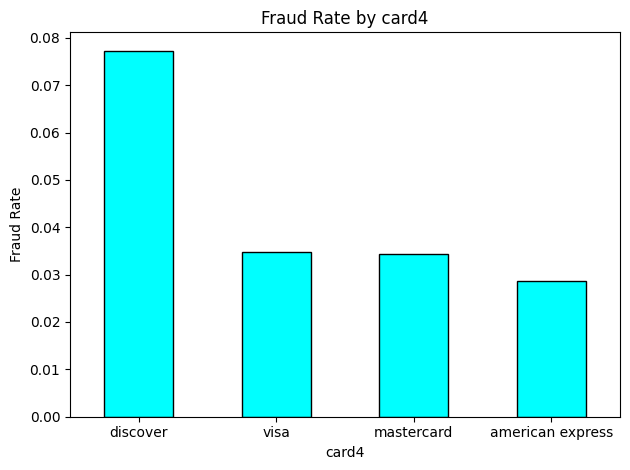

In [86]:
fraud_by_card4 = df_complete.groupby('card4')['isFraud'].mean().sort_values(ascending=False)
fraud_by_card4.plot(kind='bar', color='cyan', edgecolor='black')
plt.xlabel('card4')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by card4')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Esta gráfica demuestra parcialmente la conclusión anterior, la tarjeta discover es la que tiene más porcentaje de ser usada en transacciones fraudulentas, mientras que desmiente la hipotesis acerca de american express.

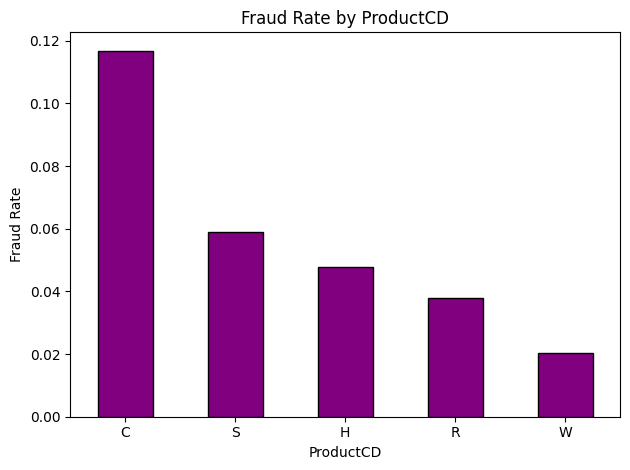

In [87]:
fraud_by_product = df_complete.groupby('ProductCD')['isFraud'].mean().sort_values(ascending=False)
fraud_by_product.plot(kind='bar', color='purple', edgecolor='black')
plt.xlabel('ProductCD')
plt.ylabel('Fraud Rate')
plt.title('Fraud Rate by ProductCD')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

En este caso la gráfica **Fraud rate by ProductCD**, aunque IEEE no comparte información acerca de que representa esta variable, se puede ver que la categoría **c** es la más relevante, la cual puede servir mucho más adelante para el modelado.

## **Conclusiones del EDA**

Gracias al análisis realizado sobre el dataset IEEE-CIS, con 590,540 transacciones,
se pueden identificar cuatro hallazgos clave que guiarán el modelado:

El primero, y más evidente, es el gran desbalance que hay en el porcentaje de
transacciones fraudulentas, ya que son muy pocas: solo el 3.50% del total. Sin embargo,
aunque sean tan pocas transacciones fraudulentas, llegan a un promedio de casi $150
dólares por transacción, lo cual es bastante preocupante.

El segundo tiene que ver con el monto de las transacciones: las fraudulentas tienen,
en promedio, un poco más de dinero que las legítimas, lo que podría tener sentido al
intentar sacar dinero, aunque no es determinante por sí solo.

El tercero, gracias a la gráfica de **Fraud Rate by Device Type**, los dispositivos
móviles son los más usados al momento de las transacciones fraudulentas en promedio,
lo que puede tener sentido por temas de seguridad, aunque hay que ver cómo se
comportará en el modelado.

Y el cuarto, a partir de las variables categóricas **card4** y **ProductCD**: la tarjeta
Discover es la que tiene más porcentaje de ser usada en transacciones fraudulentas, y
aunque IEEE no comparte información acerca de qué representa cada categoría de ProductCD,
la categoría **C** es la más relevante, la cual puede servir mucho más adelante para
el modelado.